In [1]:
import tensorflow as tf
import numpy as np
print(tf.__version__)
!python --version

2.20.0
Python 3.12.13


In [6]:
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [4]:
test_path = '/content/drive/MyDrive/Colab Notebooks/covid19/covid19/test'
train_path = '/content/drive/MyDrive/Colab Notebooks/covid19/covid19/train'

In [5]:
batch_size = 32
img_height = img_width = 100

In [7]:
import tensorflow as tf

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_path,
    image_size=(img_height, img_width),
    label_mode='int',
    batch_size=batch_size
)

Found 253 files belonging to 3 classes.


In [8]:
val_ds = tf.keras.preprocessing.image_dataset_from_directory(test_path,
                                                              image_size=(img_height, img_width),
                                                              label_mode='int', #sparse_categorical_crossentropy
                                                              batch_size=batch_size)

Found 66 files belonging to 3 classes.


In [9]:
train_ds.prefetch(1)


<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 100, 100, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [10]:
class_names = train_ds.class_names
num_classes = len(class_names)
print(class_names)

['Covid', 'Normal', 'Viral Pneumonia']


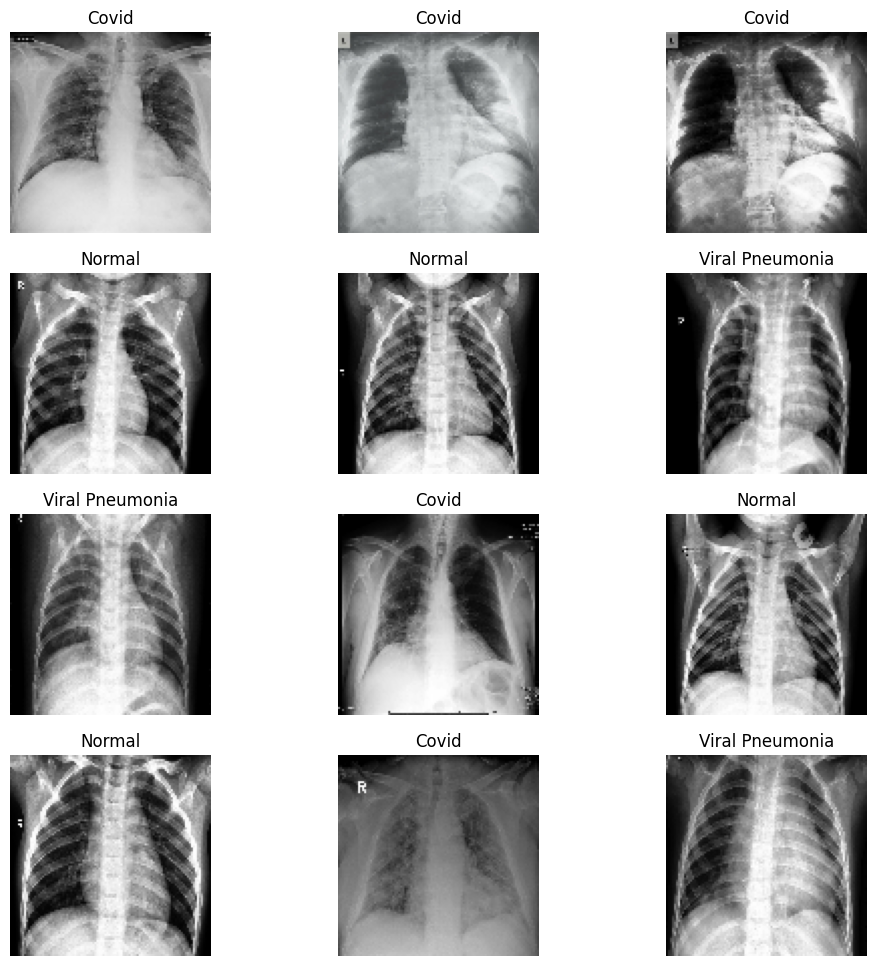

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 12))
for img, label in val_ds.take(1):
    for i in range(12):
        ax = plt.subplot(4, 3, i + 1)
        plt.imshow(img[i].numpy().astype("uint8"))
        plt.title(class_names[label[i]])
        plt.axis("off")

In [13]:
norm_layer = tf.keras.layers.Rescaling(1./255)

zoom_layer = tf.keras.layers.RandomZoom(
    height_factor=(0.1,0.3),
    width_factor=(0.1,0.3)
)

rot_layer = tf.keras.layers.RandomRotation(factor=0.2)

In [14]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Input, Flatten, Dense, BatchNormalization, Dropout
from tensorflow.keras.models import Sequential

In [21]:
def get_model(num_classes):

    model = Sequential([
        norm_layer,
        zoom_layer,
        rot_layer,

        Conv2D(16, (5, 5), padding='same', activation='relu'),
        MaxPooling2D((2,2)),
        BatchNormalization(),
        Dropout(0.3),

        Conv2D(16, (3, 3), padding='same', activation='relu'),
        MaxPooling2D((2,2), strides=(2,2)),
        Dropout(0.3),

        Flatten(),

        Dense(256, activation='relu'),
        Dropout(0.5),

        Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(
            from_logits=False
        ),
        metrics=['accuracy']
    )

    return model

In [22]:
model = get_model(num_classes)

In [23]:
history = model.fit(train_ds, validation_data=val_ds, epochs=50)

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 70s 8s/step - accuracy: 0.4229 - loss: 1.7380 - val_accuracy: 0.5000 - val_loss: 1.0535
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 753ms/step - accuracy: 0.5138 - loss: 1.2027 - val_accuracy: 0.4697 - val_loss: 1.0340
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 465ms/step - accuracy: 0.6364 - loss: 0.8549 - val_accuracy: 0.5758 - val_loss: 1.0065
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 465ms/step - accuracy: 0.6917 - loss: 0.7111 - val_accuracy: 0.5303 - val_loss: 1.0053
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 711ms/step - accuracy: 0.6877 - loss: 0.7309 - val_accuracy: 0.5909 - val_loss: 0.9792
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 470ms/step - accuracy: 0.7154 - loss: 0.6302 - val_accuracy: 0.5606 - val_loss: 0.9724
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 493ms/step - accuracy: 0.7352 - loss: 0.5977 - val_accuracy: 0.6061 - val_loss: 0.9519
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 768ms/step - accuracy: 0.7549 - loss: 0.5556 - val_accuracy: 0.6061 - val_loss: 0

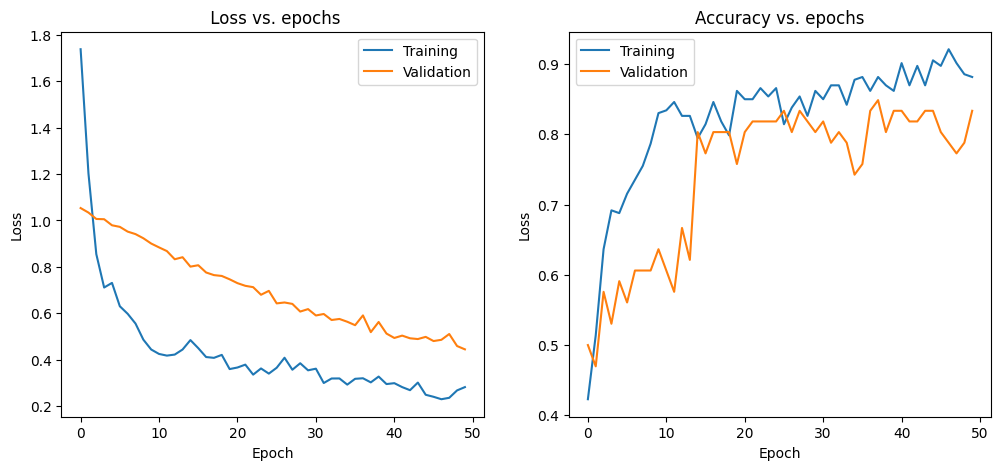

In [24]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(12, 5))

fig.add_subplot(121)

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title(' Loss vs. epochs')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='best')

fig.add_subplot(122)

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy vs. epochs')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='best')

plt.show()

In [25]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

test_datagen = ImageDataGenerator()

test_ds = test_datagen.flow_from_directory(
    test_path,
    target_size=(img_height, img_width),
    batch_size = 1,
    class_mode = 'categorical',
    color_mode = "rgb",
    shuffle=False,
    seed = 2021
)

Found 66 images belonging to 3 classes.


In [26]:
test_ds.reset()
predictions = model.predict(test_ds, steps=len(test_ds.filenames), verbose=1)

66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step


NameError: name 'np' is not defined